# CNN Architecture Comparison on Cross-Dataset Image Classification
## Standard Convolution vs Dilated Convolution — CIFAR-10 ➜ STL-10

---

### Project Overview

This notebook investigates how two CNN variants behave when trained on one image dataset and evaluated on a structurally similar but visually different one — a setup known as **cross-dataset generalization**.

| | Details |
|---|---|
| **Training data** | CIFAR-10 — 50,000 low-res images across 10 object categories |
| **Test data** | STL-10 — higher resolution images of the same 10 categories |
| **Model A** | StandardCNN — classic convolution blocks |
| **Model B** | DilatedCNN — expanded receptive field via atrous convolutions |
| **Framework** | PyTorch |
| **Runtime** | T4 GPU (Google Colab) |



---
## 1 · Configuration & Environment

All project settings live in a single config dictionary. This makes it easy to change hyperparameters in one place without hunting through the notebook.

In [ ]:
!pip install -q torchmetrics codecarbon thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.6 MB/s eta 0:00:00


In [ ]:
import torch, random, os, time, shutil
import numpy as np

# ── Project config (single source of truth) ──────────────────────────────────
CFG = {
    'seed'        : 7,
    'img_size'    : 32,          # both datasets will be resized to this
    'batch_size'  : 64,
    'epochs'      : 20,
    'lr'          : 3e-4,        # slightly higher than original
    'weight_decay': 5e-4,
    'dropout'     : 0.4,
    'label_smooth': 0.1,
    'num_classes' : 10,
    'channels'    : 3,           # RGB
    'save_dir'    : '/content/checkpoints',
    'drive_dir'   : '/content/drive/MyDrive/CNN_Comparison_Project',
    'class_names' : ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck'],
    # STL-10 class index → CIFAR-10 class index
    # STL-10 has 'monkey' (idx 7) which has no CIFAR-10 match → mapped to -1
    'stl_to_cifar': {0:0, 1:2, 2:1, 3:3, 4:4, 5:5, 6:7, 7:-1, 8:8, 9:9},
}

# ── Reproducibility ───────────────────────────────────────────────────────────
def lock_seed(s):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True

lock_seed(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(CFG['save_dir'], exist_ok=True)

print('=' * 50)
print(f"  Device       : {DEVICE}")
print(f"  Batch size   : {CFG['batch_size']}")
print(f"  Epochs       : {CFG['epochs']}")
print(f"  Learning rate: {CFG['lr']}")
print(f"  Seed         : {CFG['seed']}")
print('=' * 50)

  Device       : cuda
  Batch size   : 64
  Epochs       : 20
  Learning rate: 0.0003
  Seed         : 7


---
## 2 · Model Architecture Definitions

Both models are defined **before** loading data — the architecture is the core of the experiment, so it comes first.

Both use the same building block (`ConvBlock`) to keep things clean and avoid repetition.

**Key difference:**
- `StandardCNN` uses `dilation=1` everywhere → each filter looks at a 3×3 neighbourhood
- `DilatedCNN` increases dilation in deeper layers → filters look at a wider area (5×5, 7×7 effective) without extra parameters

In [ ]:
import torch.nn as nn

# ── Reusable building block ───────────────────────────────────────────────────
class ConvBlock(nn.Module):
    """Conv → BatchNorm → ReLU, with optional dilation and pooling."""
    def __init__(self, in_ch, out_ch, dilation=1, pool=True):
        super().__init__()
        pad = dilation  # keeps spatial size stable when dilation changes
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=pad, dilation=dilation),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# ── Shared classifier head ────────────────────────────────────────────────────
def build_head(in_features, num_classes, dropout):
    """Fully-connected classification head reused by both models."""
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout),
        nn.Linear(512, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout / 2),
        nn.Linear(256, num_classes),
    )


# ── Model A: Standard CNN ─────────────────────────────────────────────────────
class StandardCNN(nn.Module):
    """
    Four convolutional blocks with standard (non-dilated) convolutions.
    Receptive field grows purely through max-pooling.
    """
    def __init__(self, cfg):
        super().__init__()
        C, D, N = cfg['channels'], cfg['dropout'], cfg['num_classes']
        self.encoder = nn.Sequential(
            ConvBlock(C,   64,  dilation=1, pool=True),
            ConvBlock(64,  128, dilation=1, pool=True),
            ConvBlock(128, 256, dilation=1, pool=True),
            ConvBlock(256, 512, dilation=1, pool=False),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = build_head(512, N, D)

    def forward(self, x):
        return self.head(self.encoder(x))


# ── Model B: Dilated CNN ──────────────────────────────────────────────────────
class DilatedCNN(nn.Module):
    """
    Same structure as StandardCNN but deeper layers use increasing dilation.
    This expands the receptive field without adding parameters or losing resolution.
    """
    def __init__(self, cfg):
        super().__init__()
        C, D, N = cfg['channels'], cfg['dropout'], cfg['num_classes']
        self.encoder = nn.Sequential(
            ConvBlock(C,   64,  dilation=1, pool=True),   # normal
            ConvBlock(64,  128, dilation=2, pool=True),   # 2x wider view
            ConvBlock(128, 256, dilation=2, pool=True),   # 2x wider view
            ConvBlock(256, 512, dilation=4, pool=False),  # 4x wider view
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = build_head(512, N, D)

    def forward(self, x):
        return self.head(self.encoder(x))


# Quick sanity check — run a fake batch through both models
def verify_models(cfg, device):
    dummy = torch.zeros(2, cfg['channels'], cfg['img_size'], cfg['img_size']).to(device)
    for cls, name in [(StandardCNN, 'StandardCNN'), (DilatedCNN, 'DilatedCNN')]:
        m = cls(cfg).to(device)
        out = m(dummy)
        total_params = sum(p.numel() for p in m.parameters())
        print(f"{name:15s} → output: {tuple(out.shape)}  |  params: {total_params/1e6:.2f}M")

verify_models(CFG, DEVICE)

StandardCNN     → output: (2, 10)  |  params: 1.95M
DilatedCNN      → output: (2, 10)  |  params: 1.95M


---
## 3 · Library Imports & Transform Pipelines

Image transforms are defined here as named pipelines.
- `augment_pipe` → applied only during training (adds variety to help the model generalize)
- `clean_pipe` → applied during validation and testing (no randomness, pure normalization)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms
from torchmetrics import Accuracy, F1Score, CohenKappa, MatthewsCorrCoef, AUROC, Recall, Precision
from thop import profile
from codecarbon import EmissionsTracker

S = CFG['img_size']
MEAN, STD = [0.5]*3, [0.5]*3   # normalize RGB channels to [-1, 1]

augment_pipe = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

clean_pipe = transforms.Compose([
    transforms.Resize((S, S)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print('Transform pipelines ready.')
print(f'  augment_pipe : {len(augment_pipe.transforms)} steps (training only)')
print(f'  clean_pipe   : {len(clean_pipe.transforms)} steps (val/test)')

Transform pipelines ready.
  augment_pipe : 7 steps (training only)
  clean_pipe   : 3 steps (val/test)


---
## 4 · Dataset Construction & Label Alignment

CIFAR-10 and STL-10 share 9 out of 10 classes, but the **class indices are in different order** and STL-10 has a 'monkey' class with no CIFAR-10 equivalent.

We handle this with a `DatasetWrapper` class that:
- Remaps STL-10 labels to match CIFAR-10 ordering
- Filters out samples with no matching class (monkey)
- Exposes `.targets` so the sampler and metrics work correctly

In [ ]:
class DatasetWrapper(Subset):
    """
    Wraps an STL-10 dataset split:
    - Remaps labels using the provided mapping dict
    - Drops any sample whose mapped label is -1 (no CIFAR-10 equivalent)
    - Stores remapped labels in .targets for compatibility
    """
    def __init__(self, base_ds, label_map, class_names):
        raw_labels = np.array(base_ds.labels)
        mapped     = np.array([label_map[l] for l in raw_labels])
        keep_idx   = np.where(mapped >= 0)[0]

        super().__init__(base_ds, keep_idx)
        self.targets = mapped[keep_idx].tolist()
        self.classes = class_names

    def __getitem__(self, idx):
        img, _ = super().__getitem__(idx)
        return img, self.targets[idx]


# ── Download & build all splits ───────────────────────────────────────────────
print('Downloading CIFAR-10...')
cifar_train = datasets.CIFAR10('/content/cifar10', train=True,  download=True, transform=augment_pipe)
cifar_test  = datasets.CIFAR10('/content/cifar10', train=False, download=True, transform=clean_pipe)

print('Downloading STL-10...')
_stl_train = datasets.STL10('/content/stl10', split='train', download=True, transform=clean_pipe)
_stl_test  = datasets.STL10('/content/stl10', split='test',  download=True, transform=clean_pipe)

stl_val  = DatasetWrapper(_stl_train, CFG['stl_to_cifar'], CFG['class_names'])
stl_test = DatasetWrapper(_stl_test,  CFG['stl_to_cifar'], CFG['class_names'])

print()
print(f'CIFAR-10 train : {len(cifar_train):>6,} images')
print(f'CIFAR-10 test  : {len(cifar_test):>6,} images  (not used — STL-10 is test set)')
print(f'STL-10   val   : {len(stl_val):>6,} images  (after removing monkey class)')
print(f'STL-10   test  : {len(stl_test):>6,} images  (after removing monkey class)')

100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


100%|██████████| 2.64G/2.64G [02:57<00:00, 14.9MB/s]



CIFAR-10 train : 50,000 images
CIFAR-10 test  : 10,000 images  (not used — STL-10 is test set)
STL-10   val   :  4,500 images  (after removing monkey class)
STL-10   test  :  7,200 images  (after removing monkey class)


In [ ]:
# ── Weighted sampler to handle class imbalance ────────────────────────────────
# CIFAR-10 is fairly balanced but we apply the sampler anyway for consistency
targets      = np.array(cifar_train.targets)
class_counts = np.bincount(targets)
weights      = 1.0 / class_counts[targets]
sampler      = WeightedRandomSampler(weights, num_samples=len(cifar_train), replacement=True)

# ── Build DataLoaders ─────────────────────────────────────────────────────────
B = CFG['batch_size']
loader = {
    'train' : DataLoader(cifar_train, batch_size=B, sampler=sampler,
                         num_workers=2, pin_memory=True, persistent_workers=True),
    'val'   : DataLoader(stl_val,    batch_size=B, shuffle=False,
                         num_workers=2, pin_memory=True, persistent_workers=True),
    'test'  : DataLoader(stl_test,   batch_size=B, shuffle=False,
                         num_workers=2, pin_memory=True, persistent_workers=True),
}

print('DataLoaders ready.')
print(f"  Train batches : {len(loader['train'])}")
print(f"  Val   batches : {len(loader['val'])}")
print(f"  Test  batches : {len(loader['test'])}")

DataLoaders ready.
  Train batches : 782
  Val   batches : 71
  Test  batches : 113


---
## 5 · Dataset Exploration & Visual Inspection

Before training anything, we look at both datasets to understand what we're working with.

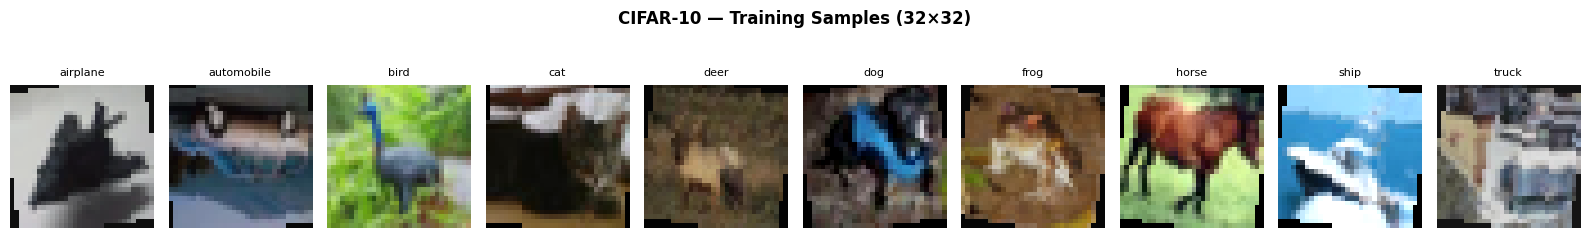

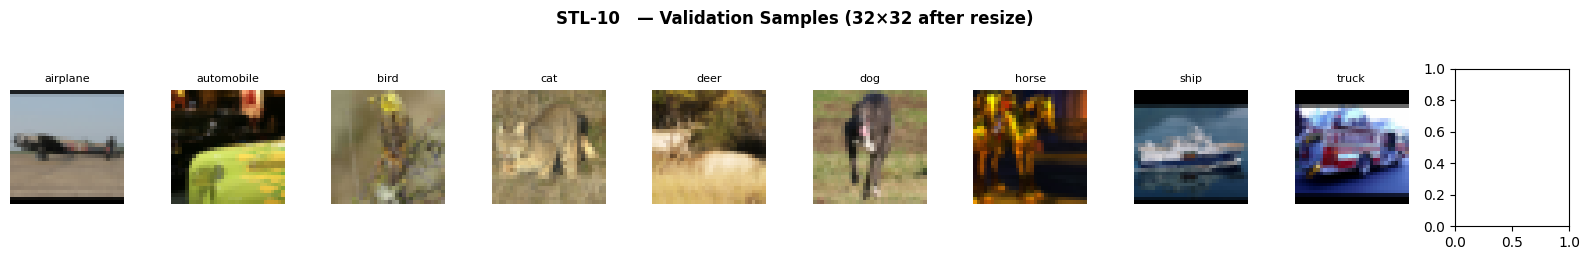

In [ ]:
# ── Show sample images from each class ───────────────────────────────────────
def plot_class_samples(dataset, title, class_names, denorm=True):
    samples = {}
    for img, lbl in dataset:
        if lbl not in samples:
            samples[lbl] = img
        if len(samples) == len(class_names):
            break

    fig, axes = plt.subplots(1, len(class_names), figsize=(16, 2.5))
    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    for ax, lbl in zip(axes, sorted(samples)):
        img = samples[lbl]
        if denorm:
            img = img * 0.5 + 0.5          # undo normalization for display
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1).numpy())
        ax.set_title(class_names[lbl], fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_class_samples(cifar_train, 'CIFAR-10 — Training Samples (32×32)', CFG['class_names'])
plot_class_samples(stl_val,     'STL-10   — Validation Samples (32×32 after resize)', CFG['class_names'])

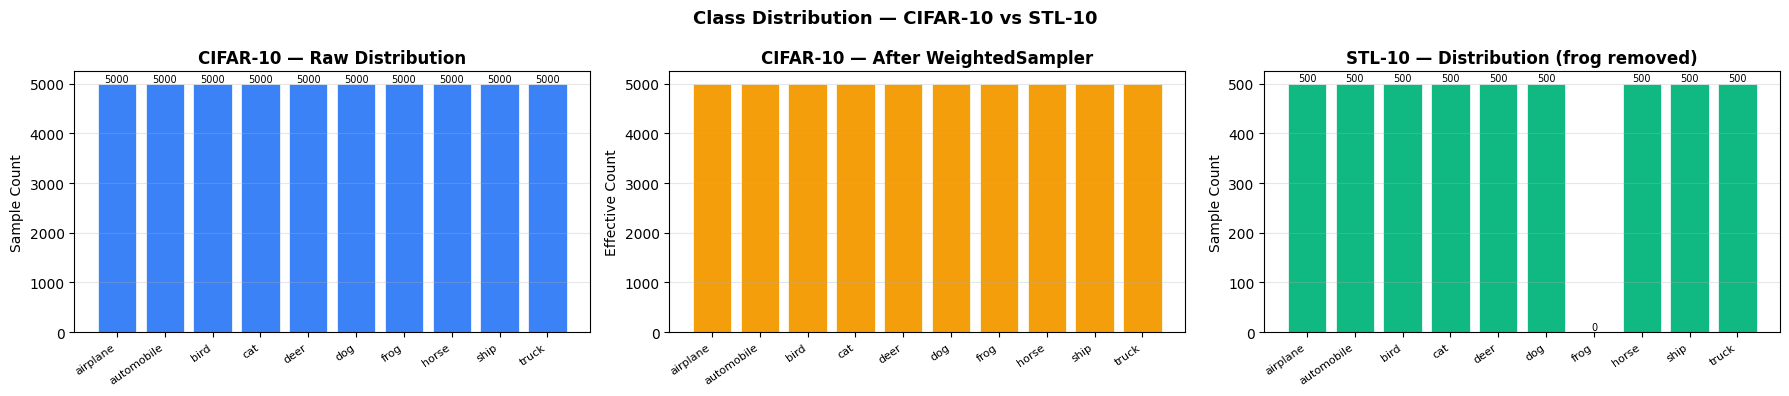

In [ ]:
# ── Class distribution analysis ───────────────────────────────────────────────
stl_counts  = np.bincount(stl_val.targets, minlength=CFG['num_classes'])
x           = np.arange(CFG['num_classes'])
names       = CFG['class_names']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Before balancing
axes[0].bar(x, class_counts, color='#3b82f6', edgecolor='white', linewidth=0.5)
axes[0].set_title('CIFAR-10 — Raw Distribution', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('Sample Count'); axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=7)

# After balancing (sampler equalizes all classes to max count)
balanced = np.full(CFG['num_classes'], class_counts.max())
axes[1].bar(x, balanced, color='#f59e0b', edgecolor='white', linewidth=0.5)
axes[1].set_title('CIFAR-10 — After WeightedSampler', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('Effective Count'); axes[1].grid(axis='y', alpha=0.3)

# STL-10
axes[2].bar(x, stl_counts, color='#10b981', edgecolor='white', linewidth=0.5)
axes[2].set_title('STL-10 — Distribution (frog removed)', fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=35, ha='right', fontsize=8)
axes[2].set_ylabel('Sample Count'); axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(stl_counts):
    axes[2].text(i, v + 5, str(v), ha='center', fontsize=7)

plt.suptitle('Class Distribution — CIFAR-10 vs STL-10', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6 · Training Engine & Experiment Runner

Training logic is wrapped in a `Trainer` class — this keeps state (history, best weights, metrics) organized per model and makes it easy to run both experiments consistently.

In [ ]:
class Trainer:
    """
    Encapsulates the full training & evaluation loop for one model.
    Tracks loss, accuracy, training time, and CO2 emissions.
    """

    def __init__(self, model, name, cfg, device):
        self.model  = model.to(device)
        self.name   = name
        self.cfg    = cfg
        self.device = device
        self.ckpt   = os.path.join(cfg['save_dir'], f'{name}.pth')

        self.criterion = nn.CrossEntropyLoss(label_smoothing=cfg['label_smooth'])
        self.optimizer = optim.AdamW(
            model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay']
        )
        self.scheduler = optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr=cfg['lr'] * 5,
            steps_per_epoch=len(loader['train']),
            epochs=cfg['epochs'],
        )

        self.history     = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
        self.best_val    = 0.0
        self.train_time  = 0.0
        self.co2_grams   = 0.0

    # ── Single epoch helpers ──────────────────────────────────────────────────
    def _train_epoch(self):
        self.model.train()
        running_loss = running_correct = total = 0
        for X, y in loader['train']:
            X, y = X.to(self.device), y.to(self.device)
            self.optimizer.zero_grad()
            logits = self.model(X)
            loss   = self.criterion(logits, y)
            loss.backward()
            self.optimizer.step()
            self.scheduler.step()
            running_loss    += loss.item() * X.size(0)
            running_correct += (logits.argmax(1) == y).sum().item()
            total           += X.size(0)
        return running_loss / total, running_correct / total

    def _eval_epoch(self, split='val'):
        self.model.eval()
        running_loss = running_correct = total = 0
        with torch.no_grad():
            for X, y in loader[split]:
                X, y   = X.to(self.device), y.to(self.device)
                logits = self.model(X)
                loss   = self.criterion(logits, y)
                running_loss    += loss.item() * X.size(0)
                running_correct += (logits.argmax(1) == y).sum().item()
                total           += X.size(0)
        return running_loss / total, running_correct / total

    # ── Full training run ─────────────────────────────────────────────────────
    def fit(self):
        print(f'\n{"─"*55}')
        print(f'  Running experiment: {self.name}')
        print(f'{"─"*55}')

        tracker = EmissionsTracker(project_name=self.name, log_level='error')
        tracker.start()
        t_start = time.time()

        for ep in range(1, self.cfg['epochs'] + 1):
            tl, ta = self._train_epoch()
            vl, va = self._eval_epoch('val')

            self.history['train_loss'].append(tl)
            self.history['val_loss'].append(vl)
            self.history['train_acc'].append(ta)
            self.history['val_acc'].append(va)

            if va > self.best_val:
                self.best_val = va
                torch.save(self.model.state_dict(), self.ckpt)

            if ep % 5 == 0 or ep == 1:
                lr_now = self.optimizer.param_groups[0]['lr']
                print(f'  ep {ep:02d}/{self.cfg["epochs"]} '
                      f'| train loss {tl:.4f} acc {ta:.3f} '
                      f'| val loss {vl:.4f} acc {va:.3f} '
                      f'| lr {lr_now:.2e}')

        self.train_time = time.time() - t_start
        self.co2_grams  = tracker.stop() * 1000

        # restore best checkpoint
        self.model.load_state_dict(torch.load(self.ckpt))

        print(f'\n  ✓ Best val acc : {self.best_val:.4f}')
        print(f'  ✓ Time elapsed : {self.train_time/60:.2f} min')
        print(f'  ✓ CO2 emitted  : {self.co2_grams:.4f} g CO2eq')
        return self

print('Trainer class ready.')

Trainer class ready.


In [ ]:
# ── Instantiate and train both models ─────────────────────────────────────────
exp_standard = Trainer(StandardCNN(CFG), 'StandardCNN', CFG, DEVICE).fit()
exp_dilated  = Trainer(DilatedCNN(CFG),  'DilatedCNN',  CFG, DEVICE).fit()

[codecarbon WARNING @ 13:16:11] Multiple instances of codecarbon are allowed to run at the same time.



───────────────────────────────────────────────────────
  Running experiment: StandardCNN
───────────────────────────────────────────────────────
  ep 01/20 | train loss 1.7697 acc 0.400 | val loss 2.7491 acc 0.254 | lr 1.57e-04
  ep 05/20 | train loss 1.2541 acc 0.672 | val loss 2.3787 acc 0.374 | lr 1.40e-03
  ep 10/20 | train loss 1.0100 acc 0.786 | val loss 2.3341 acc 0.425 | lr 1.22e-03
  ep 15/20 | train loss 0.8305 acc 0.862 | val loss 2.1990 acc 0.466 | lr 4.24e-04
  ep 20/20 | train loss 0.7510 acc 0.898 | val loss 2.2363 acc 0.470 | lr 6.03e-09

  ✓ Best val acc : 0.4740
  ✓ Time elapsed : 12.85 min
  ✓ CO2 emitted  : 9.1204 g CO2eq

───────────────────────────────────────────────────────
  Running experiment: DilatedCNN
───────────────────────────────────────────────────────
  ep 01/20 | train loss 1.8124 acc 0.370 | val loss 2.4891 acc 0.264 | lr 1.57e-04
  ep 05/20 | train loss 1.3418 acc 0.632 | val loss 2.3231 acc 0.330 | lr 1.40e-03
  ep 10/20 | train loss 1.1057 acc 0

---
## 7 · Results & Metric Analysis

We evaluate both models on the **STL-10 test set** — images they have never seen.

All metrics are computed in one pass using `torchmetrics`.

In [ ]:
def collect_outputs(model, device):
    """Run model on test set and return predictions, probabilities, and true labels."""
    model.eval()
    preds_list, probs_list, labels_list = [], [], []
    with torch.no_grad():
        for X, y in loader['test']:
            logits = model(X.to(device))
            probs_list.append(torch.softmax(logits, dim=1).cpu())
            preds_list.append(logits.argmax(1).cpu())
            labels_list.append(y)
    return torch.cat(preds_list), torch.cat(probs_list), torch.cat(labels_list)


def evaluate_model(experiment):
    """Compute all metrics for one trained experiment and return as a dict."""
    preds, probs, labels = collect_outputs(experiment.model, DEVICE)
    n  = CFG['num_classes']
    kw = dict(task='multiclass', num_classes=n)

    metrics = {
        'Model'           : experiment.name,
        'Accuracy'        : round(Accuracy(**kw)(preds, labels).item(), 4),
        'F1 Macro'        : round(F1Score(**kw, average='macro')(preds, labels).item(), 4),
        'Precision Macro' : round(Precision(**kw, average='macro')(preds, labels).item(), 4),
        'Recall Macro'    : round(Recall(**kw, average='macro')(preds, labels).item(), 4),
        'ROC-AUC'         : round(AUROC(**kw, average='macro')(probs, labels).item(), 4),
        'Cohen Kappa'     : round(CohenKappa(**kw)(preds, labels).item(), 4),
        'MCC'             : round(MatthewsCorrCoef(**kw)(preds, labels).item(), 4),
    }

    # Model complexity
    dummy = torch.zeros(1, CFG['channels'], CFG['img_size'], CFG['img_size']).to(DEVICE)
    flops, params = profile(experiment.model, inputs=(dummy,), verbose=False)
    metrics['FLOPs (M)']       = round(flops  / 1e6, 2)
    metrics['Params (M)']      = round(params / 1e6, 2)
    metrics['Train Time (min)']= round(experiment.train_time / 60, 2)
    metrics['CO2 (g)']         = round(experiment.co2_grams, 4)

    return metrics


print('Computing metrics on STL-10 test set...')
results = pd.DataFrame([
    evaluate_model(exp_standard),
    evaluate_model(exp_dilated),
]).set_index('Model')

print('\n===== TEST SET RESULTS (STL-10) =====')
print(results.T.to_string())

Computing metrics on STL-10 test set...


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)



===== TEST SET RESULTS (STL-10) =====
Model             StandardCNN  DilatedCNN
Accuracy               0.4660      0.4356
F1 Macro               0.4160      0.3873
Precision Macro        0.4194      0.3949
Recall Macro           0.4194      0.3920
ROC-AUC                0.6951      0.6852
Cohen Kappa            0.4074      0.3734
MCC                    0.4126      0.3780
FLOPs (M)             59.2900     59.2900
Params (M)             1.9500      1.9500
Train Time (min)      12.8500     12.6200
CO2 (g)                9.1204      9.1335


---
## 8 · Comparative Visualization

Three charts:
1. **Learning curves** — how loss and accuracy evolved during training
2. **Performance metrics** — bar chart comparing all 7 quality metrics
3. **Efficiency metrics** — FLOPs, parameters, training time, CO2

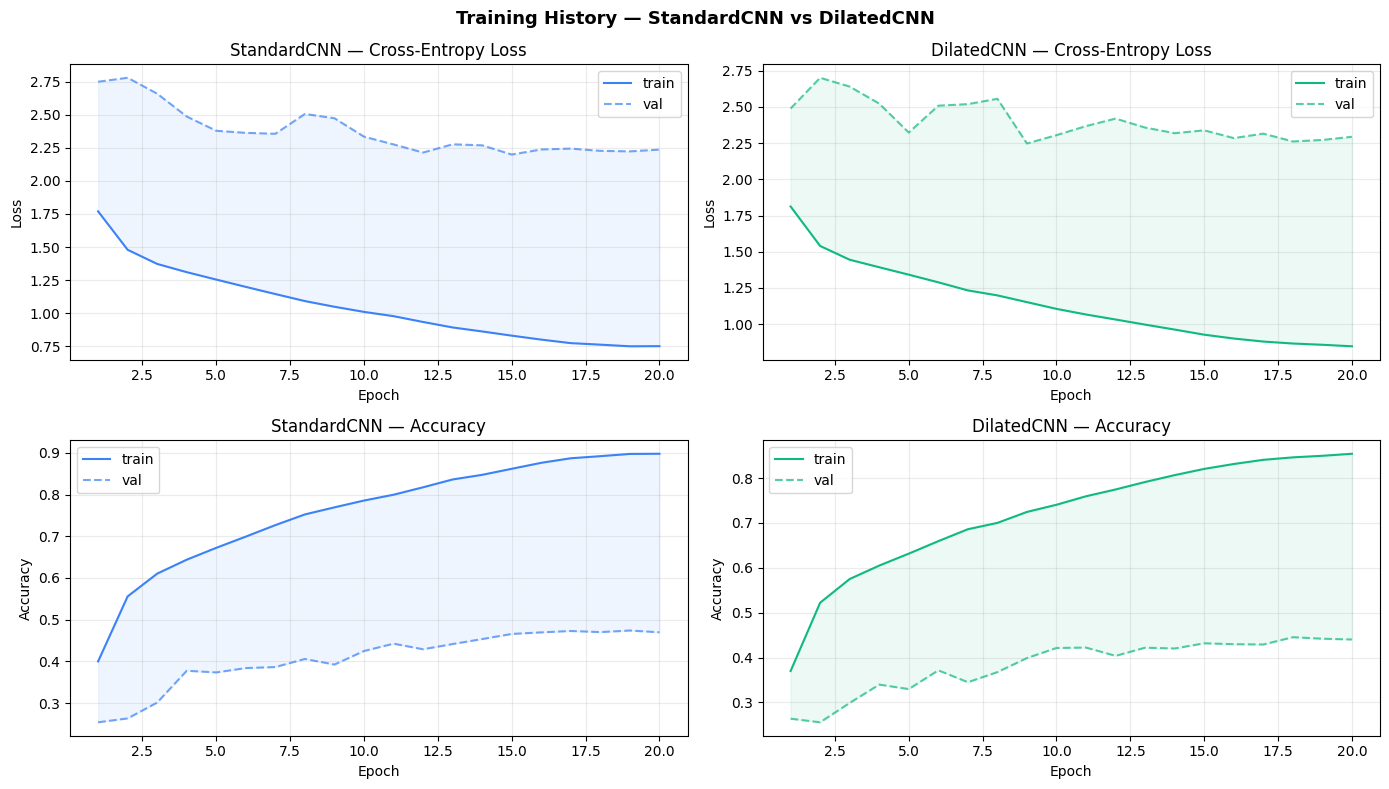

In [ ]:
# ── Learning curves ───────────────────────────────────────────────────────────
COLOR = {'StandardCNN': '#3b82f6', 'DilatedCNN': '#10b981'}
epochs_x = range(1, CFG['epochs'] + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Training History — StandardCNN vs DilatedCNN', fontsize=13, fontweight='bold')

for col, exp in enumerate([exp_standard, exp_dilated]):
    c = COLOR[exp.name]
    h = exp.history

    axes[0][col].plot(epochs_x, h['train_loss'], color=c, label='train')
    axes[0][col].plot(epochs_x, h['val_loss'],   color=c, label='val', linestyle='--', alpha=0.7)
    axes[0][col].fill_between(epochs_x, h['train_loss'], h['val_loss'], alpha=0.08, color=c)
    axes[0][col].set_title(f'{exp.name} — Cross-Entropy Loss')
    axes[0][col].set_xlabel('Epoch'); axes[0][col].set_ylabel('Loss')
    axes[0][col].legend(); axes[0][col].grid(alpha=0.25)

    axes[1][col].plot(epochs_x, h['train_acc'], color=c, label='train')
    axes[1][col].plot(epochs_x, h['val_acc'],   color=c, label='val', linestyle='--', alpha=0.7)
    axes[1][col].fill_between(epochs_x, h['train_acc'], h['val_acc'], alpha=0.08, color=c)
    axes[1][col].set_title(f'{exp.name} — Accuracy')
    axes[1][col].set_xlabel('Epoch'); axes[1][col].set_ylabel('Accuracy')
    axes[1][col].legend(); axes[1][col].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1429/2091788219.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, fontsize=9)
/tmp/ipykernel_1429/2091788219.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, fontsize=9)
/tmp/ipykernel_1429/2091788219.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, fontsize=9)
/tmp/ipykernel_1429/2091788219.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, fontsize=9)


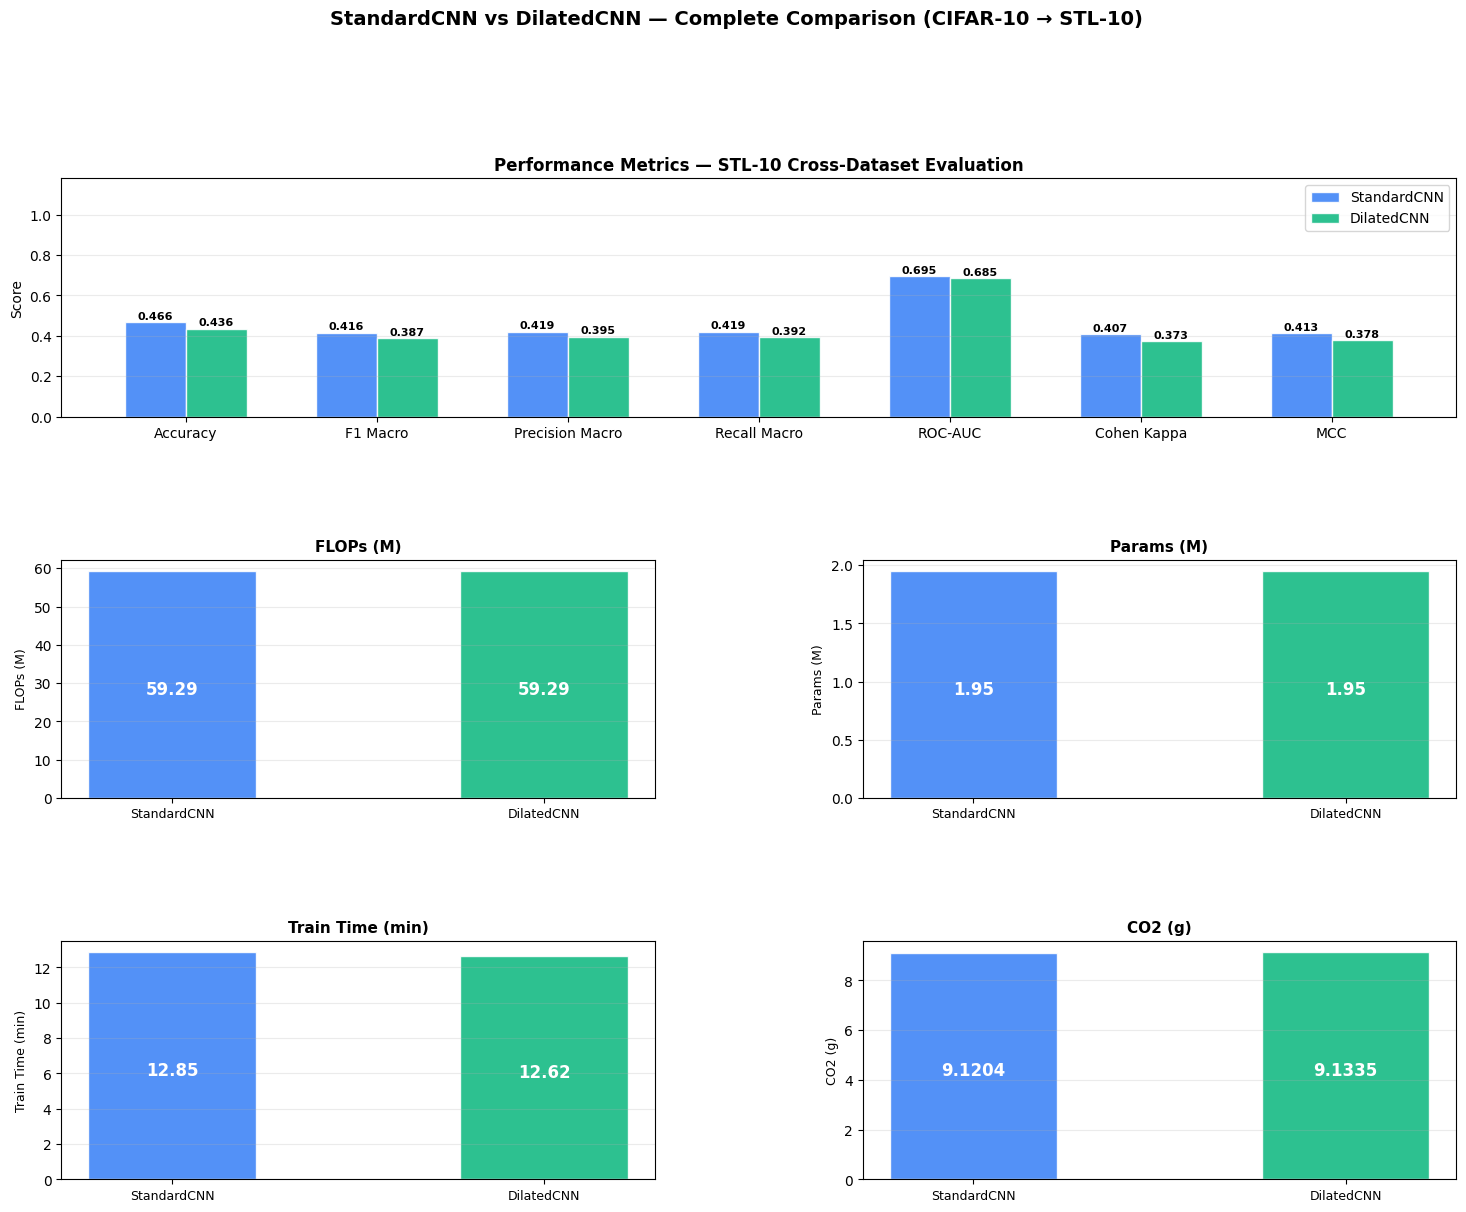


===== FINAL SUMMARY =====
Model             StandardCNN  DilatedCNN
Accuracy               0.4660      0.4356
F1 Macro               0.4160      0.3873
Precision Macro        0.4194      0.3949
Recall Macro           0.4194      0.3920
ROC-AUC                0.6951      0.6852
Cohen Kappa            0.4074      0.3734
MCC                    0.4126      0.3780
FLOPs (M)             59.2900     59.2900
Params (M)             1.9500      1.9500
Train Time (min)      12.8500     12.6200
CO2 (g)                9.1204      9.1335


In [ ]:
# ── Performance & efficiency comparison charts ────────────────────────────────
perf_metrics = ['Accuracy', 'F1 Macro', 'Precision Macro', 'Recall Macro', 'ROC-AUC', 'Cohen Kappa', 'MCC']
eff_metrics  = ['FLOPs (M)', 'Params (M)', 'Train Time (min)', 'CO2 (g)']

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.6, wspace=0.35)

models  = results.index.tolist()
colors  = [COLOR[m] for m in models]
x       = np.arange(len(perf_metrics))
bar_w   = 0.32

# Performance metrics
ax_perf = fig.add_subplot(gs[0, :])
for i, (m, c) in enumerate(zip(models, colors)):
    vals = [results.loc[m, col] for col in perf_metrics]
    bars = ax_perf.bar(x + i*bar_w, vals, bar_w, label=m, color=c, alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax_perf.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.006,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax_perf.set_xticks(x + bar_w/2)
ax_perf.set_xticklabels(perf_metrics, fontsize=10)
ax_perf.set_ylim(0, 1.18)
ax_perf.set_ylabel('Score')
ax_perf.set_title('Performance Metrics — STL-10 Cross-Dataset Evaluation', fontweight='bold', fontsize=12)
ax_perf.legend(fontsize=10); ax_perf.grid(axis='y', alpha=0.25)

# Efficiency subplots
for idx, col in enumerate(eff_metrics):
    r, c_col = divmod(idx, 2)
    ax = fig.add_subplot(gs[r + 1, c_col])
    vals = [results.loc[m, col] for m in models]
    bars = ax.bar(models, vals, color=colors, alpha=0.88, edgecolor='white', width=0.45)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.48,
                str(v), ha='center', va='center', color='white', fontweight='bold', fontsize=12)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_ylabel(col, fontsize=9)
    ax.grid(axis='y', alpha=0.25)
    ax.set_xticklabels(models, fontsize=9)

fig.suptitle('StandardCNN vs DilatedCNN — Complete Comparison (CIFAR-10 → STL-10)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('/content/full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n===== FINAL SUMMARY =====')
print(results.T.to_string())

---
## 9 · Export & Storage

All outputs are saved to Google Drive for easy access.

In [ ]:
# Create a local output folder inside Colab
OUTPUT_DIR = '/content/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Model weights
for exp in [exp_standard, exp_dilated]:
    dst = os.path.join(OUTPUT_DIR, f'{exp.name}.pth')
    shutil.copy(exp.ckpt, dst)
    print(f'Saved: {dst}')



# Plots
for fname in ['learning_curves.png', 'full_comparison.png', 'class_distributions.png']:
    shutil.copy(f'/content/{fname}', os.path.join(OUTPUT_DIR, fname))
    print(f'Saved: {fname}')

print(f'\nAll outputs saved locally → {OUTPUT_DIR}')
print('Contents:', os.listdir(OUTPUT_DIR))

Saved: /content/outputs/StandardCNN.pth
Saved: /content/outputs/DilatedCNN.pth
Saved: /content/outputs/results.csv
Saved: learning_curves.png
Saved: full_comparison.png
Saved: class_distributions.png

All outputs saved locally → /content/outputs
Contents: ['full_comparison.png', 'results.csv', 'StandardCNN.pth', 'class_distributions.png', 'learning_curves.png', 'DilatedCNN.pth']
